## Loading the InstaNovo model

We first install the latest instanovo from PyPi

In [ ]:
try:
  import instanovo
except ImportError:
  !uv pip install "instanovo[cu126]>=1.2.2" pyopenms-viz
  print('Installation complete. Restarting runtime to apply changes...')
  import os
  os.kill(os.getpid(), 9)

Using Python 3.12.13 environment at: /usr
Resolved 154 packages in 2.39s
Prepared 37 packages in 13.30s
Uninstalled 6 packages in 622ms
Installed 37 packages in 239ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + boto3==1.41.5
 + botocore==1.41.5
 + bravado==11.1.0
 + bravado-core==6.1.1
 + deprecated==1.3.1
 + fastobo==0.14.1
 + hydra-core==1.3.2
 + instanovo==1.2.2
 + jaxtyping==0.3.9
 + jiwer==4.0.0
 + jmespath==1.1.0
 + jsonref==1.1.0
 - lxml==6.0.2
 + lxml==4.9.4
 + matchms==0.29.0
 + monotonic==1.6
 + neptune==1.14.0.post2
 - nvidia-nccl-cu12==2.27.5
 + nvidia-nccl-cu12==2.27.3
 - pandas==2.2.2
 + pandas==2.3.3
 + pickydict==0.5.0
 + pubchempy==1.0.5
 + pyopenms-viz==1.0.1
 + pyteomics==4.7.5
 + rapidfuzz==3.14.3
 + rdkit==2024.9.6
 + s3fs==2025.3.0
 + s3transfer==0.15.0
 + signalrcore==1.0.2
 + sparsestack==0.6.4
 + spectrum-utils==0.5.0
 + swagger-spec-validator==3.0.4
 - torch==2.10.0+cu128
 + torch==2.8.0
 + transfusion-asr==0.1.0
 - triton==3.6.0
 + triton==3.4.0
 + wadl

In [3]:
# Filter warnings and set logging level
import warnings
import logging

warnings.filterwarnings("ignore", module="matplotlib")
warnings.filterwarnings("ignore", module="torch")
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("rdkit").setLevel(logging.WARNING)

We can use `instanovo version` to check the version of InstaNovo (the transformer-based model), InstaNovo+ (the diffusion-based model) and some of their dependencies.

In [4]:
!instanovo version

┏━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Package    ┃ Version ┃
┡━━━━━━━━━━━━╇━━━━━━━━━┩
│ InstaNovo  │ 1.2.2   │
│ InstaNovo+ │ 1.2.2   │
│ NumPy      │ 2.0.2   │
│ PyTorch    │ 2.8.0   │
└────────────┴─────────┘


Import the transformer-based InstaNovo model.

In [5]:
from instanovo.transformer.model import InstaNovo

Set the device to GPU if available (recommended), otherwise use CPU.

In [6]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

InstaNovo supports automatic model downloads. You can see the IDs of the pretrained models that are available.

In [7]:
InstaNovo.get_pretrained()

['instanovo-v1.2.0',
 'instanovo-v1.1.0',
 'instanovo-v1.0.0',
 'instanovo-phospho-v1.0.0']

And download the model checkpoint given the ID.

In [8]:
model, config = InstaNovo.from_pretrained("instanovo-v1.2.0")
model = model.to(device).eval()

instanovo-v1.2.0.ckpt: 100%|██████████| 362M/362M [00:11<00:00, 32.9MiB/s]


## Loading the dataset

In [22]:
from instanovo.utils.data_handler import SpectrumDataFrame

sdf = SpectrumDataFrame.load_mzml("/content/wastewater_Sample1_1.mzML")

In [23]:
df = sdf.to_pandas().copy()

print("shape:", df.shape)
print(df.columns.tolist())
print(df.dtypes)
display(df.head(3))

shape: (17100, 8)
['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array']
scan_number           int64
sequence             object
precursor_mass      float64
precursor_mz        float64
precursor_charge      int64
retention_time      float64
mz_array             object
intensity_array      object
dtype: object


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array
0,40,,1480.379368,741.19696,2,0.167837,"[136.38525390625, 143.05569458007812, 149.0447...","[1134.8853759765625, 1557.720458984375, 1477.0..."
1,166,,1366.393408,684.20398,2,0.711286,"[118.62577056884766, 149.045166015625, 167.055...","[1169.7818603515625, 3631.05126953125, 1690.52..."
2,257,,1514.430768,758.22266,2,1.103036,"[112.7114486694336, 112.89521789550781, 117.23...","[1333.8302001953125, 1128.4227294921875, 1125...."


In [24]:
null_counts = df.isnull().sum()
print(null_counts)

scan_number         0
sequence            0
precursor_mass      0
precursor_mz        0
precursor_charge    0
retention_time      0
mz_array            0
intensity_array     0
dtype: int64


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

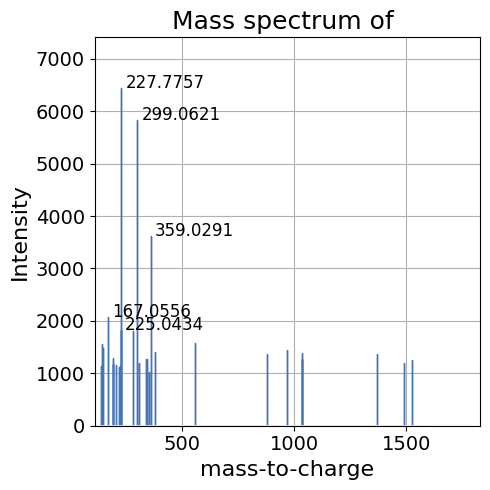

In [29]:
import pandas as pd

pd.options.plotting.backend = "ms_matplotlib"
row = sdf[0]
row_df = pd.DataFrame({"mz": row["mz_array"], "intensity": row["intensity_array"]})
row_df.plot(
    kind="spectrum",
    x="mz",
    y="intensity",
    annotate_mz=True,
    bin_method="none",
    annotate_top_n_peaks=5,
    aggregate_duplicates=True,
    title=f"Mass spectrum of {row['sequence']}",
);

In [32]:

Ecoli_sdf = SpectrumDataFrame.load_mzml("/content/Ecoli_EV_1.mzML")

In [33]:
Ecoli_df = Ecoli_sdf.to_pandas().copy()

print("shape:", Ecoli_df.shape)
print(Ecoli_df.columns.tolist())
print(Ecoli_df.dtypes)
display(Ecoli_df.head(3))

shape: (10881, 8)
['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array']
scan_number           int64
sequence             object
precursor_mass      float64
precursor_mz        float64
precursor_charge      int64
retention_time      float64
mz_array             object
intensity_array      object
dtype: object


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array
0,95,,832.727148,417.37085,2,0.407458,"[108.90433879457866, 108.90479357490754, 108.9...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 677.9..."
1,169,,1301.626602,434.88281,3,0.726686,"[108.9043793591056, 108.90483413943026, 108.90...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 411.7..."
2,277,,840.644268,421.32941,2,1.194676,"[108.90433891446301, 108.90479369479279, 108.9...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 577.4..."


In [34]:
ecoli_null_counts = df.isnull().sum()
print(ecoli_null_counts)

scan_number            0
sequence               0
precursor_mass         0
precursor_mz           0
precursor_charge       0
retention_time         0
mz_array               0
intensity_array        0
num_peaks              0
tic                    0
base_peak_intensity    0
mz_min                 0
mz_max                 0
mz_range               0
dtype: int64


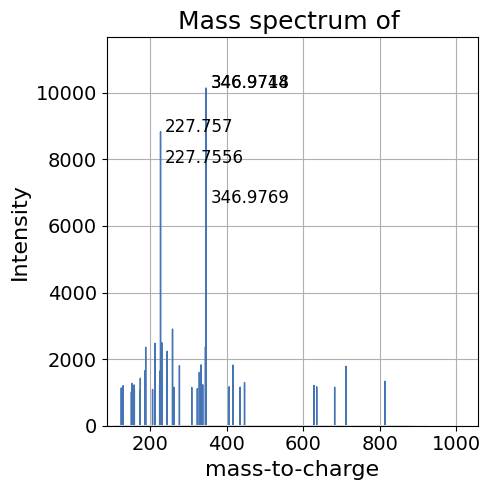

In [35]:
import pandas as pd

pd.options.plotting.backend = "ms_matplotlib"
row = Ecoli_sdf[0]
row_df = pd.DataFrame({"mz": row["mz_array"], "intensity": row["intensity_array"]})
row_df.plot(
    kind="spectrum",
    x="mz",
    y="intensity",
    annotate_mz=True,
    bin_method="none",
    annotate_top_n_peaks=5,
    aggregate_duplicates=True,
    title=f"Mass spectrum of {row['sequence']}",
);